# Scenario Builder — plug in your own hardware, rebates, and rates

Companion to `HOME_ENERGY_LAB.ipynb`. That notebook reports what Phase 0-3 found with one fixed
set of hardware/rebate/rate assumptions (real BC Hydro rates, real-ish 2026 Vancouver solar/battery
pricing). **This notebook is meant to be edited.** Hardware prices change, rebate programs expire
and get replaced, and if you live somewhere other than BC, the rate structure is completely
different. Every one of those is a plain Python dict in `scenario_engine.py` — the "EDIT ME" cells
below show exactly which fields to change.

Every scenario still runs through the SAME real machinery as the main lab: Phase 1's winning GP
forecast dispatch policy, `dispatch_sim.py`'s battery/grid simulator, and the real 2017-2025
Vancouver weather+load record. Only the **economics layer** — hardware cost, rebate rule, rate
structure — is a parameter here.

**Two real 2026 hardware trends this notebook models explicitly** (both flagged by Fraser as
increasingly relevant, both real and sourced in `research/06_alternative_hardware_options.md`):
1. **Battery-only arbitrage with cheaper batteries** — Anker SOLIX and similar brands now sell
   battery capacity well below Tesla Powerwall-class pricing ($700-$1,300 USD/kWh vs. Powerwall's
   ~$1,185 CAD/kWh once inverter/subpanel costs are folded in).
2. **Balcony solar** ("Balkonkraftwerk") — an ~800W plug-in kit, increasingly popular in Germany
   (with real city subsidies in some cases) and now emerging in the US. **BC/Vancouver's grid-tie
   legality for this class of device is not confirmed** — modeled here as a cost/payback anchor
   only, not a claim it's legal to install as-is in BC.

> Same disclaimer as the main lab: illustrative and educational, anchored to real data and
> real-ish rate/rebate structures, but not a substitute for a real quote or professional advice.

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
from daily_agg import build_hourly, build_daily, TRAIN_YEARS, TEST_YEARS
from load_model import hourly_load_kw
import gp_forecast_model as gpf
import scenario_engine as se

INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
C0, C1, C2, C3, C4 = "#9a9890", "#c9622a", "#e0a83a", "#1baf7a", "#2a78d6"
CAT_COLORS = [C4, C1, C3, C2, C0, "#8a4fd1"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})

## Setup — fit the real dispatch model once (shared by every scenario below)

This is the same one-time real-data setup `capacity_sizing.py`'s Phase 3 used: fit Method 2's GP
forecast on the real 2016 training year, load the real 2017-2025 held-out record. Every scenario
below reuses this fit — only the hardware/rebate/rate economics change per scenario.

In [2]:
daily = build_daily()
daily.index = daily.index.date
years = np.array([d.year for d in daily.index])
train_mask = (years >= TRAIN_YEARS[0]) & (years <= TRAIN_YEARS[1])
train_daily = daily.loc[train_mask]
print(f"fitting Method 2 GP forecast on {len(train_daily)} real training days...")
gp = gpf.fit(train_daily)
net_load_series = daily["net_load_kwh"]

hourly = build_hourly()
test_hourly = hourly[hourly.index.year.isin(range(TEST_YEARS[0], TEST_YEARS[1] + 1))].copy()
test_hourly["load_kw"] = hourly_load_kw(test_hourly["temperature_2m"].values, test_hourly.index)
n_years = TEST_YEARS[1] - TEST_YEARS[0] + 1
print(f"real held-out record: {TEST_YEARS[0]}-{TEST_YEARS[1]} ({n_years} years)")

fitting Method 2 GP forecast on 366 real training days...


real held-out record: 2017-2025 (9 years)


## EDIT ME — hardware, rebate, and rate presets

`scenario_engine.py` ships real, sourced presets. **Override any field here** without touching the
engine file — e.g. if a rebate program changes, a battery brand drops in price, or you're modeling
a different utility's rates entirely. The dicts below start as exact copies of the shipped presets;
edit the copies, not the originals.

In [3]:
# ---- EDIT ME: hardware presets -----------------------------------------
solar_options = {k: dict(v) for k, v in se.SOLAR_OPTIONS.items()}
battery_options = {k: dict(v) for k, v in se.BATTERY_OPTIONS.items()}
rate_presets = {k: dict(v) for k, v in se.RATE_PRESETS.items()}

# Example override -- suppose the BC solar rebate cap rises to $6,000 CAD next year:
# solar_options["bc_generic_rooftop"]["rebate_cap"] = 6000.0

# Example override -- suppose you found a cheaper Anker SOLIX bundle at $600 USD/kWh:
# battery_options["anker_solix_low"]["unit_cost"] = 600.0

# Example override -- add your own utility's flat rate (EDIT the numbers, not the structure):
# rate_presets["my_utility"] = dict(
#     label="My utility (EDIT ME)", tiers=[(float("inf"), 0.18)],
#     basic_charge_per_month=10.0, tod_discount=0.0, tod_surcharge=0.0,
#     offpeak_hours=set(), peak_hours=set(),
# )

rate = rate_presets["bc_hydro_2026"]
for name, hw in solar_options.items():
    print(f"solar  [{name:20s}] {hw['label']}")
for name, hw in battery_options.items():
    print(f"battery[{name:20s}] {hw['label']}")

solar  [bc_generic_rooftop  ] Generic BC rooftop solar
solar  [balcony_solar_de    ] German Balkonkraftwerk (800W, Berlin/Munich subsidy)
solar  [balcony_solar_us    ] US balcony/plug-in solar kit (800W, no dedicated subsidy)
battery[tesla_powerwall     ] Tesla Powerwall 3-class
battery[anker_solix_low     ] Anker SOLIX (low end of real 2026 range)
battery[anker_solix_high    ] Anker SOLIX (high end of real 2026 range)
battery[no_battery          ] No battery


## Named scenario comparison

Six real, distinct hardware configurations, all run through the identical simulation: the Phase-3
cost-optimal baseline, the 8kW+Powerwall reference used throughout Phases 1-2, an 8kW+Anker-SOLIX
substitution (same solar, cheaper battery), and two balcony-solar-only scenarios (DE/US), plus a
no-hardware-at-all baseline for the payback comparison.

In [4]:
SCENARIOS = [
    dict(key="baseline_no_hardware", label="No solar, no battery (baseline)",
         solar_kw=0.0, battery_kwh=0.0, solar_opt="bc_generic_rooftop", battery_opt="no_battery"),
    dict(key="phase3_optimal", label="Phase 3 cost-optimal: 4kW solar, no battery",
         solar_kw=4.0, battery_kwh=0.0, solar_opt="bc_generic_rooftop", battery_opt="no_battery"),
    # Added 2026-08-05: once export is credited (RS 2289), 6kW lands within $7/yr of 4kW --
    # a statistical tie, so the runner-up belongs in the comparison rather than being hidden
    # behind a single "optimal" label. See RESULTS_PHASE3.md.
    dict(key="phase3_runner_up", label="Phase 3 runner-up: 6kW solar, no battery",
         solar_kw=6.0, battery_kwh=0.0, solar_opt="bc_generic_rooftop", battery_opt="no_battery"),
    dict(key="reference_powerwall", label="8kW solar + Tesla Powerwall-class (Phase 1-2 reference)",
         solar_kw=8.0, battery_kwh=13.5, solar_opt="bc_generic_rooftop", battery_opt="tesla_powerwall"),
    dict(key="anker_low", label="8kW solar + Anker SOLIX (low-end 2026 pricing)",
         solar_kw=8.0, battery_kwh=13.5, solar_opt="bc_generic_rooftop", battery_opt="anker_solix_low"),
    dict(key="balcony_de", label="Balcony solar only (Germany, subsidized, 0.8kW)",
         solar_kw=0.8, battery_kwh=0.0, solar_opt="balcony_solar_de", battery_opt="no_battery"),
    dict(key="balcony_us", label="Balcony solar only (US, unsubsidized, 0.8kW)",
         solar_kw=0.8, battery_kwh=0.0, solar_opt="balcony_solar_us", battery_opt="no_battery"),
]

scenario_results = {}
for s in SCENARIOS:
    r = se.run_scenario(s["solar_kw"], s["battery_kwh"],
                        solar_options[s["solar_opt"]], battery_options[s["battery_opt"]],
                        rate, gp, net_load_series, test_hourly, n_years)
    scenario_results[s["key"]] = r
    print(f"{s['label']:52s}  total=${r['total_annual']:7,.0f}/yr  "
          f"net_capital=${r['solar_net_capital']+r['battery_net_capital']:8,.0f}  "
          f"self-suff={r['self_sufficiency']:.1%}  "
          f"fully-self-suff-days={r['frac_fully_self_sufficient_days']:.1%}")

baseline_total = scenario_results["baseline_no_hardware"]["total_annual"]
baseline_grid = scenario_results["baseline_no_hardware"]["grid_annual"]

No solar, no battery (baseline)                       total=$  1,469/yr  net_capital=$       0  self-suff=0.0%  fully-self-suff-days=0.0%


Phase 3 cost-optimal: 4kW solar, no battery           total=$  1,234/yr  net_capital=$   7,600  self-suff=25.4%  fully-self-suff-days=0.0%


Phase 3 runner-up: 6kW solar, no battery              total=$  1,245/yr  net_capital=$  12,400  self-suff=30.4%  fully-self-suff-days=0.0%


8kW solar + Tesla Powerwall-class (Phase 1-2 reference)  total=$  2,683/yr  net_capital=$  32,698  self-suff=41.3%  fully-self-suff-days=0.0%


8kW solar + Anker SOLIX (low-end 2026 pricing)        total=$  2,387/yr  net_capital=$  29,741  self-suff=41.3%  fully-self-suff-days=0.0%


Balcony solar only (Germany, subsidized, 0.8kW)       total=$  1,353/yr  net_capital=$     148  self-suff=6.9%  fully-self-suff-days=0.0%


Balcony solar only (US, unsubsidized, 0.8kW)          total=$  1,381/yr  net_capital=$     724  self-suff=6.9%  fully-self-suff-days=0.0%


### Baseline vs. options — three measures, three very different scales

Annual $ cost, net capital outlay, and self-sufficiency all move together directionally but on
wildly different scales (net capital ranges from $0 to nearly $33,000 — a 220x spread), so each
gets its own axis rather than forcing them onto one chart. Same scenario, same color, across all
three panels.

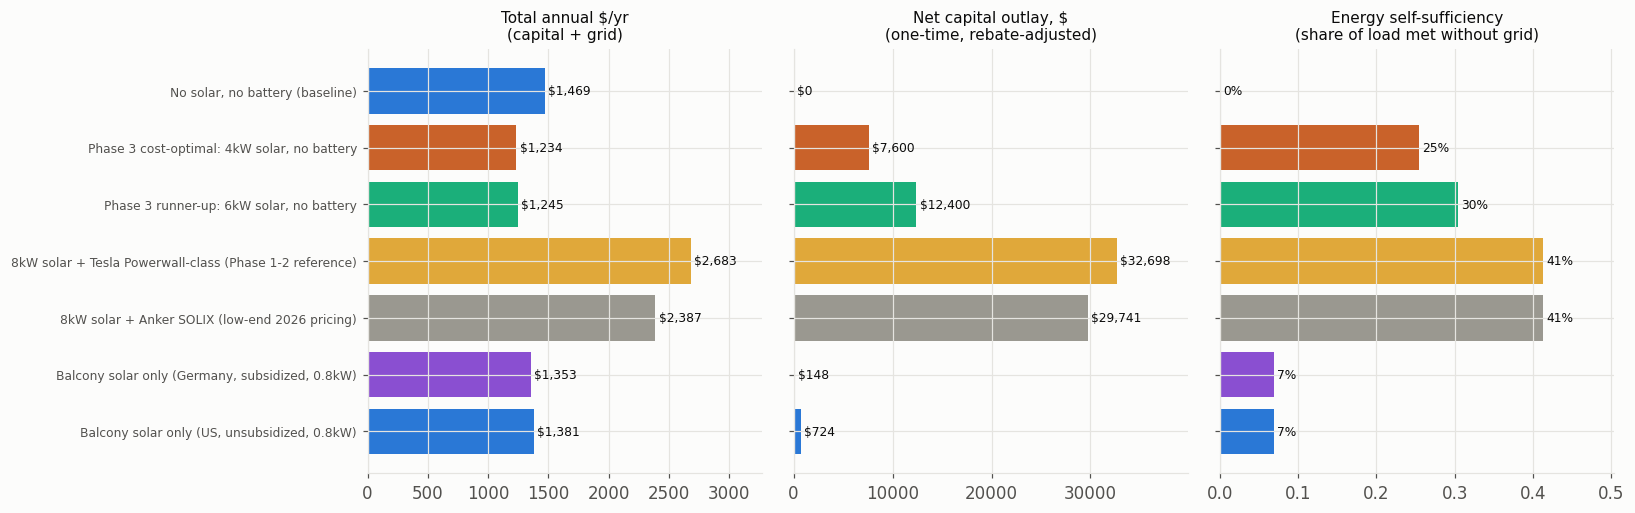

Net capital spread: $0 to $32,698 -- balcony solar delivers real self-sufficiency and a lower bill at ~0.5% of the Powerwall-class system's capital outlay.


In [5]:
scenario_order = [s["key"] for s in SCENARIOS]
scenario_labels = [s["label"] for s in SCENARIOS]
scenario_colors = [CAT_COLORS[i % len(CAT_COLORS)] for i in range(len(SCENARIOS))]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

panels = [
    ("total_annual", "Total annual $/yr\n(capital + grid)", lambda v: f"${v:,.0f}"),
    (None, "Net capital outlay, $\n(one-time, rebate-adjusted)", lambda v: f"${v:,.0f}"),
    ("self_sufficiency", "Energy self-sufficiency\n(share of load met without grid)", lambda v: f"{v:.0%}"),
]

for ax, (field, title, fmt) in zip(axes, panels):
    if field is None:
        vals = [scenario_results[k]["solar_net_capital"] + scenario_results[k]["battery_net_capital"]
                for k in scenario_order]
    else:
        vals = [scenario_results[k][field] for k in scenario_order]
    ax.barh(range(len(scenario_order)), vals, color=scenario_colors)
    ax.set_yticks(range(len(scenario_order)))
    ax.set_yticklabels(scenario_labels if ax is axes[0] else [], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()
    xmax = max(vals) if max(vals) > 0 else 1.0
    for y, v in enumerate(vals):
        ax.text(v + 0.01 * xmax, y, fmt(v), va="center", fontsize=8)
    ax.set_xlim(0, xmax * 1.22)

plt.tight_layout(); plt.show()

print("Net capital spread: "
      f"${min(scenario_results[k]['solar_net_capital']+scenario_results[k]['battery_net_capital'] for k in scenario_order):,.0f}"
      " to "
      f"${max(scenario_results[k]['solar_net_capital']+scenario_results[k]['battery_net_capital'] for k in scenario_order):,.0f}"
      " -- balcony solar delivers real self-sufficiency and a lower bill at ~0.5% of the "
      "Powerwall-class system's capital outlay.")

## Return-of-capital: real payback-year comparison

The user's explicit ask: "a return of capital scenario (5y, 6y, etc) that informs any purchasing
decision." For each hardware scenario, net capital cost ÷ annual $ saved vs. the no-hardware
baseline (simple, non-discounted payback — same convention as `scenario_engine.payback_years`).

**Important**: "annual savings" here means the reduction in the recurring **grid bill only**
(`grid_annual`), not the reduction in `total_annual` (grid + amortized capital). `total_annual`
already has the capital cost baked in via annualization — comparing `total_annual` deltas would
double-count that same capital cost against the `net_capital` numerator below and overstate real
payback. (Caught while building this notebook: an earlier draft used `total_annual` deltas, which
buried most of the 4kW scenario's real grid savings inside the "savings" already being
subtracted from itself, making a real payback look like it never pays back at all — the
grid-only comparison here is the correct one.)

**Updated 2026-08-05**: every payback figure below improved, because grid export is now credited at
BC Hydro's real Self-Generation Service Rate (RS 2289, 10¢/kWh settled per billing cycle) instead of
being valued at $0 as it previously was throughout this lab — see
`research/08_bc_hydro_export_compensation.md` and `CODE_REVIEW.md` H1. The credit is capped at each
month's energy charge, which binds harder the larger the array (a Vancouver summer pairs maximum
export with a minimal bill), so it helps small systems proportionally more than large ones.

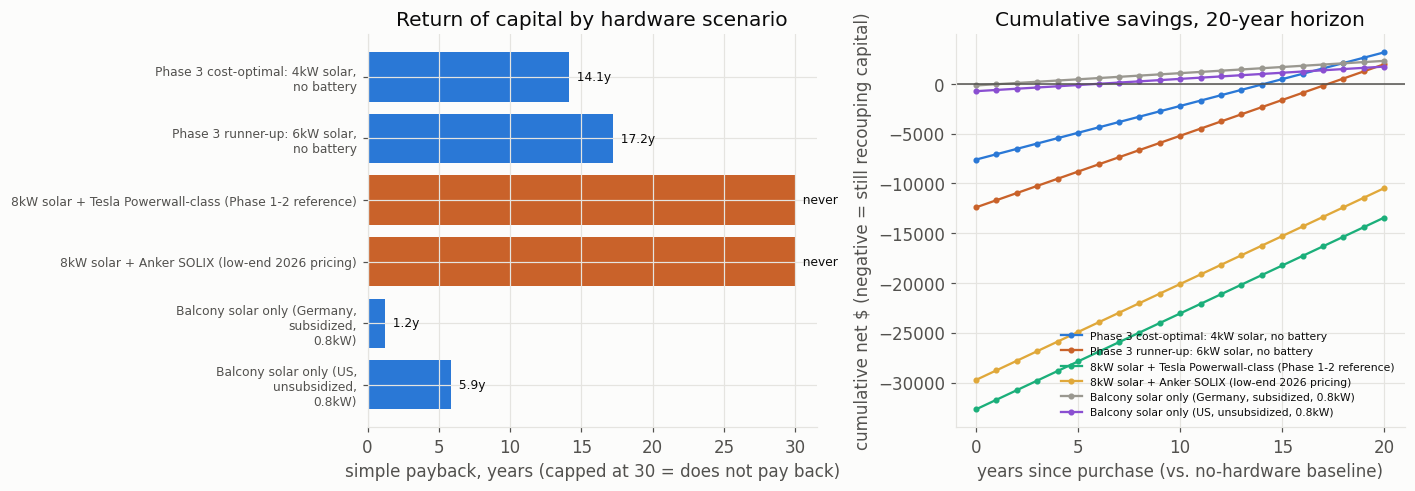

Balcony solar only (Germany, subsidized, 0.8kW)       net capital=$     148  annual savings=$   +124/yr  payback=1.2y
Balcony solar only (US, unsubsidized, 0.8kW)          net capital=$     724  annual savings=$   +124/yr  payback=5.9y
Phase 3 cost-optimal: 4kW solar, no battery           net capital=$   7,600  annual savings=$   +539/yr  payback=14.1y
Phase 3 runner-up: 6kW solar, no battery              net capital=$  12,400  annual savings=$   +719/yr  payback=17.2y
8kW solar + Anker SOLIX (low-end 2026 pricing)        net capital=$  29,741  annual savings=$   +964/yr  payback=does not pay back within 30y
8kW solar + Tesla Powerwall-class (Phase 1-2 reference)  net capital=$  32,698  annual savings=$   +964/yr  payback=does not pay back within 30y


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

payback_rows = []
for s in SCENARIOS:
    if s["key"] == "baseline_no_hardware":
        continue
    r = scenario_results[s["key"]]
    net_capital = r["solar_net_capital"] + r["battery_net_capital"]
    annual_savings = baseline_grid - r["grid_annual"]
    years = se.payback_years(net_capital, annual_savings)
    payback_rows.append(dict(label=s["label"], net_capital=net_capital,
                             annual_savings=annual_savings, payback_years=years))

ax = axes[0]
labels = [r["label"].replace(", ", ",\n") for r in payback_rows]
paybacks = [min(r["payback_years"], 30) for r in payback_rows]  # cap display at 30y for "never" cases
colors = [C4 if r["payback_years"] < 30 else C1 for r in payback_rows]
ax.barh(range(len(payback_rows)), paybacks, color=colors)
ax.set_yticks(range(len(payback_rows))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("simple payback, years (capped at 30 = does not pay back)")
ax.set_title("Return of capital by hardware scenario")
ax.invert_yaxis()
for y, r in enumerate(payback_rows):
    txt = f"{r['payback_years']:.1f}y" if r["payback_years"] < 30 else "never"
    ax.text(min(r["payback_years"], 30), y, f"  {txt}", va="center", fontsize=8)

ax = axes[1]
horizon = 20
for i, r in enumerate(payback_rows):
    yrs, cum = se.cumulative_savings_curve(r["net_capital"], r["annual_savings"], horizon_years=horizon)
    ax.plot(yrs, cum, "-o", markersize=3, color=CAT_COLORS[i % len(CAT_COLORS)], label=r["label"])
ax.axhline(0, color=INK2, linewidth=1)
ax.set_xlabel(f"years since purchase (vs. no-hardware baseline)")
ax.set_ylabel("cumulative net $ (negative = still recouping capital)")
ax.set_title("Cumulative savings, 20-year horizon")
ax.legend(frameon=False, fontsize=7, loc="lower right")

plt.tight_layout(); plt.show()

for r in sorted(payback_rows, key=lambda r: r["payback_years"]):
    pb = f"{r['payback_years']:.1f}y" if r["payback_years"] < 30 else "does not pay back within 30y"
    print(f"{r['label']:52s}  net capital=${r['net_capital']:8,.0f}  "
          f"annual savings=${r['annual_savings']:+7,.0f}/yr  payback={pb}")

## Optimizer 1 — cheapest system (any solar/battery size)

Reruns Phase 3's own grid search, but through the generalized engine — swap in `battery_options`
to see how the cost-optimal answer changes with a cheaper battery brand.

In [7]:
SOLAR_GRID = [0.0, 4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0]
BATTERY_GRID = [0.0, 13.5, 27.0, 40.5]

best_cost, rows_cost = se.optimize_grid(
    SOLAR_GRID, BATTERY_GRID, solar_options["bc_generic_rooftop"], battery_options["tesla_powerwall"],
    rate, gp, net_load_series, test_hourly, n_years, objective="cost")

print(f"Cost-optimal (Tesla-Powerwall-class pricing): {best_cost['solar_kw']:.0f}kW solar + "
      f"{best_cost['battery_kwh']:.1f}kWh battery, ${best_cost['total_annual']:,.0f}/yr, "
      f"self-sufficiency {best_cost['self_sufficiency']:.1%}")

best_cost_anker, _ = se.optimize_grid(
    SOLAR_GRID, BATTERY_GRID, solar_options["bc_generic_rooftop"], battery_options["anker_solix_low"],
    rate, gp, net_load_series, test_hourly, n_years, objective="cost")

print(f"Cost-optimal (Anker-SOLIX-low pricing):       {best_cost_anker['solar_kw']:.0f}kW solar + "
      f"{best_cost_anker['battery_kwh']:.1f}kWh battery, ${best_cost_anker['total_annual']:,.0f}/yr, "
      f"self-sufficiency {best_cost_anker['self_sufficiency']:.1%}")

Cost-optimal (Tesla-Powerwall-class pricing): 4kW solar + 0.0kWh battery, $1,234/yr, self-sufficiency 25.4%


Cost-optimal (Anker-SOLIX-low pricing):       4kW solar + 0.0kWh battery, $1,234/yr, self-sufficiency 25.4%


## Optimizer 2 — self-sufficiency, "most of the time" vs. "all of the time"

Two genuinely different targets, both real user asks: cheapest system that's **energy-weighted**
self-sufficient X% of the year ("most of the time"), vs. cheapest system with **zero grid import on
100% of days** ("all of the time" — a much harder, more expensive bar).

In [8]:
# NOTE (2026-08-05): `rows_cost` above already contains EVERY grid point this section
# needs. An earlier version called se.optimize_grid() again for each self-sufficiency
# target and once more for the "all of the time" scan -- recomputing the identical
# 8x4 grid FIVE times, each a full 9-year hourly dispatch simulation per point. That
# made this notebook take ~30 minutes for work that is ~4x smaller. The grid is now
# computed once and every question below is answered by filtering it in plain Python.
self_suff_targets = [0.3, 0.5, 0.7]
rows_self_suff = []
for target in self_suff_targets:
    feasible = [r for r in rows_cost if r["self_sufficiency"] >= target]
    best = min(feasible, key=lambda r: r["total_annual"]) if feasible else None
    rows_self_suff.append((target, best))
    if best is None:
        print(f"target >= {target:.0%} energy self-sufficient: NOT REACHABLE on this hardware grid")
    else:
        print(f"target >= {target:.0%} energy self-sufficient ('most of the time'):  "
              f"{best['solar_kw']:.0f}kW + {best['battery_kwh']:.1f}kWh, "
              f"${best['total_annual']:,.0f}/yr, actual={best['self_sufficiency']:.1%}, "
              f"fully-self-suff-days={best['frac_fully_self_sufficient_days']:.1%}")

# "All of the time" -- the harder bar: zero grid import on every single day.
best_all_time = max(rows_cost, key=lambda r: r["frac_fully_self_sufficient_days"])
print(f"\nBest achievable 'fully self-sufficient every day' on this grid: "
      f"{best_all_time['solar_kw']:.0f}kW + {best_all_time['battery_kwh']:.1f}kWh reaches "
      f"only {best_all_time['frac_fully_self_sufficient_days']:.1%} of days at zero grid import "
      f"(${best_all_time['total_annual']:,.0f}/yr) -- 'all of the time' is a much harder, more "
f"expensive bar than 'most of the time' against real Vancouver winter solar output.")

target >= 30% energy self-sufficient ('most of the time'):  6kW + 0.0kWh, $1,245/yr, actual=30.4%, fully-self-suff-days=0.0%
target >= 50% energy self-sufficient ('most of the time'):  20kW + 13.5kWh, $3,827/yr, actual=51.5%, fully-self-suff-days=0.0%
target >= 70% energy self-sufficient: NOT REACHABLE on this hardware grid

Best achievable 'fully self-sufficient every day' on this grid: 0kW + 0.0kWh reaches only 0.0% of days at zero grid import ($1,469/yr) -- 'all of the time' is a much harder, more expensive bar than 'most of the time' against real Vancouver winter solar output.


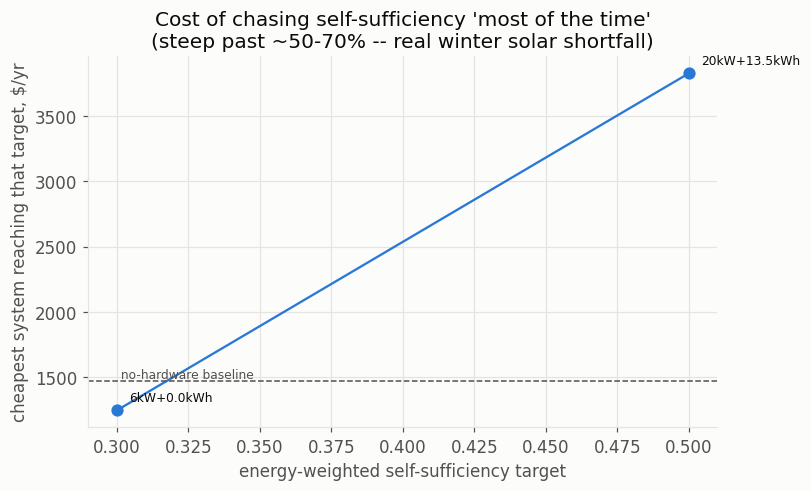

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
targets_plotted = [t for t, r in rows_self_suff if r is not None]
costs_plotted = [r["total_annual"] for t, r in rows_self_suff if r is not None]
ax.plot(targets_plotted, costs_plotted, "-o", color=C4, markersize=7)
for t, r in rows_self_suff:
    if r is not None:
        ax.annotate(f"{r['solar_kw']:.0f}kW+{r['battery_kwh']:.1f}kWh",
                    (t, r["total_annual"]), textcoords="offset points", xytext=(8, 6), fontsize=8)
ax.axhline(baseline_total, color=INK2, linestyle="--", linewidth=1)
ax.text(targets_plotted[0], baseline_total, " no-hardware baseline", fontsize=8, color=INK2, va="bottom")
ax.set_xlabel("energy-weighted self-sufficiency target")
ax.set_ylabel("cheapest system reaching that target, $/yr")
ax.set_title("Cost of chasing self-sufficiency 'most of the time'\n(steep past ~50-70% -- real winter solar shortfall)")
plt.tight_layout(); plt.show()

## A real finding this lab surfaced: is balcony solar actually legal to install in BC?

The payback numbers above make balcony solar look like the clear rational choice under BC Hydro's
current rate/rebate structure — a fraction of the capital, real self-sufficiency, and by far the
shortest payback of anything tested. Before treating that as an actionable recommendation, this
was checked directly against BC's real regulatory requirements
(`research/07_bc_balcony_solar_legal_status.md`), not assumed.

**Real finding: as of 2026-08-04, there is no legal simplified path to install balcony/plug-in
solar in BC.** BC Hydro's own customer-generation application page (fetched live) confirms every
grid-tied system — regardless of size — needs a licensed/certified installer, an electrical permit
where applicable, and a formal interconnection application through BC Hydro's approval process.
There is no exemption carved out for a ~800W plug-in kit; it is processed identically to an 8kW
rooftop array. This is the direct opposite of Germany's real rule (VDE-AR-N 4105), which explicitly
permits up to 800W of plug-in solar without an electrician — the exact simplicity that makes it cheap
and popular there. A real, in-motion BC Green MLA effort to legalize it in 2026 was noted but not
independently verified against a primary legislative source.

**The economics and the feasibility are two separate findings, and this lab now has both, honestly
stated**: balcony solar's payback advantage is real and correctly computed — but a BC household
today can't currently capture the "no electrician, no professional install" cost/friction advantage
that makes those numbers work, without going through the same licensed-install pathway required for
any other grid-tied system. If that regulatory gap closes (as it already has in parts of the US and
the EU), this lab's own numbers say it would meaningfully shift the cost-optimal choice at the low
end of the BC market — a concrete, evidence-based case for exactly that policy change, not just a
hardware recommendation.

## Closing note — what this whole lab showed, honestly

Three real findings this lab produced, none assumed going in:
1. **The regime-aware/VoI machinery didn't help here — and after a 2026-08-05 re-run, neither did
   the plain GP forecast.** Phase 1's cheapest dispatch policy consumes *no fitted model at all* (a
   calendar rule plus a fixed battery reserve); the soft-EM regime layer loses to a constant reserve
   even when verified to fire on the right days; Phase 2's posterior variance adds nothing across
   the entire cost-ratio range. A genuinely useful negative result, consistent with
   `VOI_DISPATCH_PATTERN.md`'s own cross-lab finding that this mechanism is niche, not a default
   upgrade. Knowing when the fancy machinery *doesn't* earn its keep is as real a finding as knowing
   when it does — provided you first check it *could* have helped, which is exactly what the
   original version of this lab failed to do (see `CODE_REVIEW.md`).
2. **Capital cost dominates the purchasing decision far more than dispatch cleverness does** — the
   spread between the cheapest and most expensive tested hardware configuration is a ~220x
   difference in net capital ($148 to $32,698) for total annual costs that differ by less than 2x.
   At BC Hydro's real (comparatively low) electricity rates and real (modest)
   rebate caps, no dispatch algorithm can out-optimize the raw economics of what hardware to buy in
   the first place — this is a genuinely different regime than a higher-price-per-kWh, higher-solar-
   irradiance jurisdiction would produce, where the same battery/solar hardware could look
   completely different on a cost basis. The lab's own scenario engine is built to test that shift
   directly (swap `rate_presets` for a different jurisdiction's real rates).
3. **A real regulatory gap, not just a hardware gap, is the actual barrier to this lab's own
   cheapest, fastest-payback answer** — the balcony-solar finding above.

This notebook is meant to be re-run whenever a real number changes: a hardware price drops, a
rebate program is renewed or replaced, a regulation changes, or you're modeling a different address
entirely. The underlying dispatch simulation (Phase 1's real, GP-forecast-driven battery/grid
policy, run over the real 2017-2025 Vancouver weather+load record) never has to change — only the
`solar_options` / `battery_options` / `rate_presets` dicts in the EDIT ME cell above.